# Sigprofiler from Alexandrov, in python
## SJD expanded clones: pt3, pt6 and pt14
Using the mappable genome


In [1]:
import pandas as pd
import json
from tqdm.notebook import tqdm
import pybedtools
pd.set_option('display.max_columns', 500)

In [2]:
samples_dict = json.load(open('sample_ids/sample_sjd_ids.json','rb'))
samples_dict['pt14']

{'normal': 'AQ5174',
 'tumor1': 'AX4928',
 'tumor2': 'AX4929',
 'sex': 'female',
 'clone1': 'AX4958',
 'clone2': 'AX4961'}

In [3]:
samples_dict = {pt:samples_dict[pt] for pt in samples_dict.keys() if pt in ['pt3','pt6','pt14']}
samples_dict['pt14'].pop('tumor2')
samples2_dict = {samples_dict[pt][tumor]:tumor for pt in samples_dict.keys() for tumor in samples_dict[pt].keys() if tumor != 'sex'}
samples_list = [pt+'_'+tumor[0]+tumor[-1] for pt in samples_dict.keys() for tumor in samples_dict[pt].keys() if tumor not in ['normal','sex']]
samples_list


['pt3_t1',
 'pt3_t2',
 'pt3_c1',
 'pt3_c2',
 'pt6_t1',
 'pt6_t2',
 'pt6_c1',
 'pt6_c2',
 'pt14_t1',
 'pt14_c1',
 'pt14_c2']

## Analyse results

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

/home/msanchezg/miniconda3/envs/rhabdoids/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [5]:
sbs_color_dict = {'SBS1':'orange',
                 'SBS2':'olive',
                 'SBS3':'mediumpurple',
                 'SBS5':'skyblue',
                 'SBS7a':'teal',
                 'SBS18':'royalblue',
                 'SBS12':'seagreen',
                 'SBS13':'purple',
                 'SBS17a':'green',
                 'SBS17b':'forestgreen',
                 'SBS31':'firebrick',
                 'SBS32':'plum',
                 'SBS35':'lightcoral',
                 'SBS36':'slateblue',
                 'SBS40a':'turquoise',
                 'SBS45':'steelblue',
                 'SBS60':'darkseagreen',
                 'SBS84':'moccasin',
                 'SBS90':'violet'}
greys = ['gainsboro','lightgrey','lightgray','silver','darkgrey','darkgray','grey','gray','dimgrey','dimgray','slategrey']


In [6]:
def color_sigs (sigs):

    colors_dict = {}
    colors_list = []
    i = 0
    for sig in sigs:
        if 'potential' in sig:
            color = greys[i]
            i+=1
        elif sig in sbs_color_dict.keys():
            color = sbs_color_dict[sig]
        else:
            color = greys[i]
            i+=1
            pass
        colors_dict[sig] = color
        colors_list.append(color)
    return colors_dict,colors_list

def color_sigs2 (sigs):

    colors_dict = {}
    colors_list = []
    i = 0
    for sig in sigs:
        if 'potential' in sig:
            color = greys[i]
            i+=1
        elif sig in ['SBS31','SBS35']:
            color = sbs_color_dict[sig]
        else:
            color = greys[i]
            i+=1
            pass
        colors_dict[sig] = color
        colors_list.append(color)
    return colors_dict,colors_list

def change_name (sample,samples_dict,samples2_dict):
    tumor_id = sample.split('_vs_')[0]
    normal_id = sample.split('_vs_')[1]
    print(tumor_id,normal_id)
    pt = [ pt for pt in samples_dict.keys() if samples_dict[pt]['normal']==normal_id]
    pt = pt[0]
    t = samples2_dict[tumor_id]
    sample2 = pt +'_'+t[0]+t[-1]
    return sample2

ttmt_dict = {'AX4912':'naive',
            'AX4914':'naive',
            'AX4915':'StJude',
            'AX4916':'naive',
            'AX4918':'naive',
            'AX4919':'StJude',
            'AX4920':'Boston',
            'AX4921':'Boston',
            'AX4922':'COG',
            'AX4930':'naive',
            'AX4924':'naive',
            'AX4925':'mP6',
            'AX4926':'mP6',
            'AX4927':'EU-RHAB',
            'AX4928':'MSKCC',
            'AX4929':'MSKCC',
            'AX4923':'ifo/doxo/radio',
            'AX4931':'naive',
            'AX4932':'naive',
            'AX4933':'naive',
            'AX4934':'naive',
            'AX4935':'naive',
            'AX4936':'naive',
            'AX4937':'mP6',
            'AX4938':'naive',
            'AX4951':'naive',
            'AX4940':'mP6'}


In [7]:
tumor_vs_normal = [samples_dict[pt][t]+'_vs_'+samples_dict[pt]['normal'] for pt in samples_dict.keys() for t in [tt for tt in samples_dict[pt].keys() if tt not in ['sex','normal']] ]
tumor_vs_normal

['AX4914_vs_AX4895',
 'AX4915_vs_AX4895',
 'AX4946_vs_AX4895',
 'AX4947_vs_AX4895',
 'AX4945_vs_AX4898',
 'AX4921_vs_AX4898',
 'AX4942_vs_AX4898',
 'AX4943_vs_AX4898',
 'AX4928_vs_AQ5174',
 'AX4958_vs_AQ5174',
 'AX4961_vs_AQ5174']

In [8]:
df = pd.read_csv('signature_analysis/sigprofiler/extraction/analysis/clonal/results/SBS96/Suggested_Solution/COSMIC_SBS96_Decomposed_Solution/Activities/COSMIC_SBS96_Activities.txt',sep='\t')
df = df[df['Samples'].isin(tumor_vs_normal)]
df = df[df['Samples']!='AX4929_vs_AQ5174'] #exclude pt14_t2, bad quality sample
df['Samples2'] = df['Samples'].apply(lambda x: change_name(x,samples_dict,samples2_dict))
df.index = df['Samples2']
df.drop(['Samples','Samples2'],inplace=True,axis=1)
df = df.reindex(samples_list)
display(df.sum())
exclude_sigs = ['SBS8','SBS17a','SBS17b','SBS31','SBS35','SBS46','SBS57','SBS90']
cols = [col for col in df.columns if col not in exclude_sigs]
df = df[cols]
df

AX4914 AX4895
AX4915 AX4895
AX4921 AX4898
AX4928 AQ5174
AX4942 AX4898
AX4943 AX4898
AX4945 AX4898
AX4946 AX4895
AX4947 AX4895
AX4958 AQ5174
AX4961 AQ5174


SBS1        936
SBS2         80
SBS5      16481
SBS8          0
SBS13        19
SBS17a        0
SBS17b        0
SBS18      6665
SBS31         0
SBS35      1148
SBS46         0
SBS57         0
SBS84         0
SBS90         0
dtype: int64

,SBS1,SBS2,SBS5,SBS13,SBS18,SBS84
Samples2,,,,,,
pt3_t1,102,0,456,0,128,0
pt3_t2,150,0,1691,0,0,0
pt3_c1,25,0,2652,0,1722,0
pt3_c2,29,0,2617,0,1647,0
pt6_t1,102,40,465,0,197,0
pt6_t2,96,40,403,19,159,0
pt6_c1,94,0,1409,0,508,0
pt6_c2,91,0,1499,0,557,0
pt14_t1,74,0,1283,0,0,0


Text(0.5, 0, '')

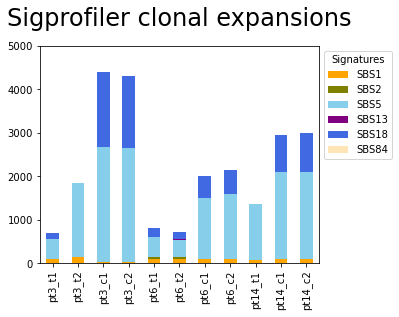

In [9]:
sigs = df.columns.tolist()
colors_dict,colors_list = color_sigs(sigs)
df.plot.bar(stacked=True,figsize=(5,4),color=colors_list)
plt.legend(title='Signatures', bbox_to_anchor=(1, 1), loc='upper left')
plt.title('Sigprofiler clonal expansions',size=24,pad=20)
ylim = 5000
plt.ylim([0,ylim])
plt.xticks(rotation=90)
plt.xlabel('')

Text(0.5, 0, '')

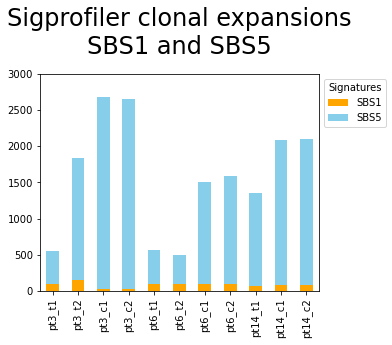

In [10]:
sigs = ['SBS1','SBS5']
df1 = df[sigs]
colors_dict,colors_list = color_sigs(sigs)
df1.plot.bar(stacked=True,figsize=(5,4),color=colors_list)
plt.legend(title='Signatures', bbox_to_anchor=(1, 1), loc='upper left')
plt.title('Sigprofiler clonal expansions\nSBS1 and SBS5',size=24,pad=20)
ylim = 3000
plt.ylim([0,ylim])
plt.xticks(rotation=90)
plt.xlabel('')

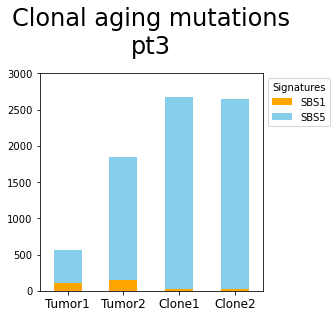

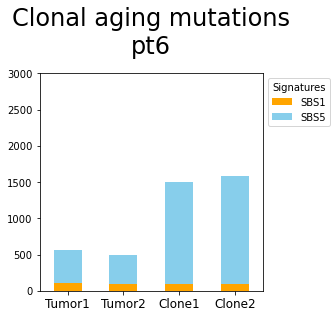

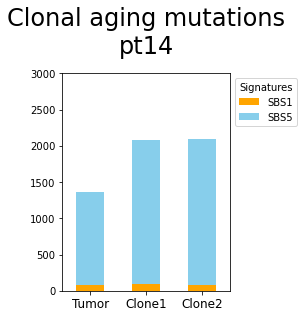

In [11]:
sigs = ['SBS1','SBS5']
for pt in ['pt3','pt6','pt14']:
	df1 = df[sigs][df.index.str.contains(pt)]
	colors_dict,colors_list = color_sigs(sigs)
	if pt == 'pt6' or pt == 'pt3':
		width = 4
		tick_labels = ['Tumor1','Tumor2','Clone1','Clone2']
	else:
		width = 3
		tick_labels = ['Tumor','Clone1','Clone2']
	df1.plot.bar(stacked=True,figsize=(width,4),color=colors_list)
	plt.legend(title='Signatures', bbox_to_anchor=(1, 1), loc='upper left')
	plt.title('Clonal aging mutations\n'+pt,size=24,pad=20)
	ylim = 3000
	plt.ylim([0,ylim])
	plt.xticks(ticks=range(0,len(df1)),labels=tick_labels,rotation=0,size=12)
	plt.xlabel('')
	plt.show()

Text(0.5, 0, '')

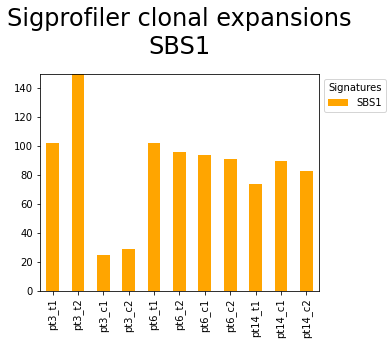

In [12]:
sigs = ['SBS1']
df1 = df[sigs]
colors_dict,colors_list = color_sigs(sigs)
df1.plot.bar(stacked=True,figsize=(5,4),color=colors_list)
plt.legend(title='Signatures', bbox_to_anchor=(1, 1), loc='upper left')
plt.title('Sigprofiler clonal expansions\nSBS1',size=24,pad=20)
ylim = 150
plt.ylim([0,ylim])
plt.xticks(rotation=90)
plt.xlabel('')

### TMB with aging muts, annotating TAB (Time after birth)

In [13]:
aging_sigs = ['SBS1','SBS5','SBS40a']

In [14]:
tab_dict = {'pt6':1.60,
            'pt3':4.79,
            'pt14' :10.10}
tab_dict

{'pt6': 1.6, 'pt3': 4.79, 'pt14': 10.1}

In [15]:
import numpy as np
import seaborn as sns
from numpy.polynomial.polynomial import polyfit
from scipy import stats

In [16]:
def plot_correlation (df1,x_col,y_col,xlabel,y_min,y_max,x_min,x_max,c,title):

    plt.figure(figsize=(7,4))
    x = df1[x_col]
    y = df1[y_col]
    plt.scatter(x=x,y=y,c=c)
    b, m = polyfit(x, y, 1)
    plt.plot(x, b + m * x, '-')

    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)

    for sample in df1.index:
        color = 'k'
        x1 = df1[x_col][(df1.index==sample)][sample]
        y1 = df1[y_col][(df1.index==sample)][sample]
        plt.text(x1*1.02,y1*1.02,s=sample,color=color)
    plt.title(title,size=22,pad=20)
    plt.ylabel('Number of mutations',size=14)
    plt.xlabel(xlabel,size=14)
    

    plt.text(x=x_min+1,y=y_max*0.95,s='Slope-intercept: y = '+str(round(m,3))+'x + '+str(round(b,3)),size=11)

    pearson_coef_pval = stats.pearsonr(x=x,y=y)
    pearson_coef = round(pearson_coef_pval[0],4)
    pearson_pval = round(pearson_coef_pval[1],4)

    plt.text(x=x_min+1,y=y_max*0.9,s='Pearson coeff: '+str(pearson_coef),size=11)
    plt.text(x=x_min+1,y=y_max*0.85,s='Pearson p-value: '+str(pearson_pval),size=11)

In [17]:
df2 = df.copy()

In [18]:
df2['age'] = df2.index.map(lambda x: tab_dict.get(x.split('_')[0],np.nan))
df2['age_embryo'] = df2['age'] + 3/4
df2

,SBS1,SBS2,SBS5,SBS13,SBS18,SBS84,age,age_embryo
Samples2,,,,,,,,
pt3_t1,102,0,456,0,128,0,4.79,5.54
pt3_t2,150,0,1691,0,0,0,4.79,5.54
pt3_c1,25,0,2652,0,1722,0,4.79,5.54
pt3_c2,29,0,2617,0,1647,0,4.79,5.54
pt6_t1,102,40,465,0,197,0,1.60,2.35
pt6_t2,96,40,403,19,159,0,1.60,2.35
pt6_c1,94,0,1409,0,508,0,1.60,2.35
pt6_c2,91,0,1499,0,557,0,1.60,2.35
pt14_t1,74,0,1283,0,0,0,10.10,10.85


In [19]:
aging_sigs = ['SBS1','SBS5']
df2['aging'] = df2[aging_sigs].sum(axis=1)
df2

,SBS1,SBS2,SBS5,SBS13,SBS18,SBS84,age,age_embryo,aging
Samples2,,,,,,,,,
pt3_t1,102,0,456,0,128,0,4.79,5.54,558
pt3_t2,150,0,1691,0,0,0,4.79,5.54,1841
pt3_c1,25,0,2652,0,1722,0,4.79,5.54,2677
pt3_c2,29,0,2617,0,1647,0,4.79,5.54,2646
pt6_t1,102,40,465,0,197,0,1.60,2.35,567
pt6_t2,96,40,403,19,159,0,1.60,2.35,499
pt6_c1,94,0,1409,0,508,0,1.60,2.35,1503
pt6_c2,91,0,1499,0,557,0,1.60,2.35,1590
pt14_t1,74,0,1283,0,0,0,10.10,10.85,1357


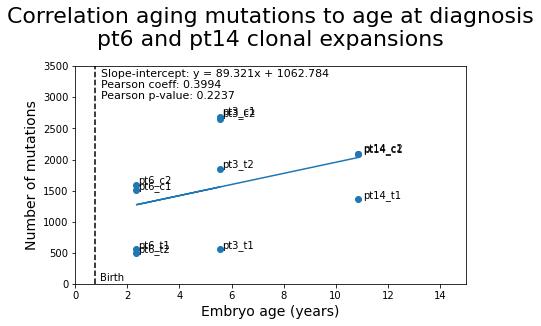

In [20]:
x_col = 'age_embryo'
y_col = 'aging'
xlabel = 'Embryo age (years)'
y_min = 0
y_max = 3500
x_min = 0
x_max = 15
c = '#1f77b4' 
title = 'Correlation aging mutations to age at diagnosis\npt6 and pt14 clonal expansions'
plot_correlation(df2,x_col,y_col,xlabel,y_min,y_max,x_min,x_max,c,title)
plt.vlines(3/4,0,y_max,color='k',linestyle='--')
plt.text(3/4+0.2,50,s='Birth')
plt.show()

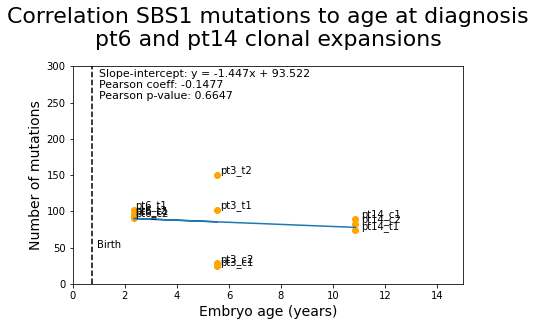

In [21]:
y_col = 'SBS1'
x_col = 'age_embryo'
xlabel = 'Embryo age (years)'
y_min = 0
y_max = 300
x_min = 0
x_max = 15
c = sbs_color_dict[y_col]
title = 'Correlation SBS1 mutations to age at diagnosis\npt6 and pt14 clonal expansions'
plot_correlation(df2,x_col,y_col,xlabel,y_min,y_max,x_min,x_max,c,title)
plt.vlines(3/4,0,y_max,color='k',linestyle='--')
plt.text(3/4+0.2,50,s='Birth')
plt.show()

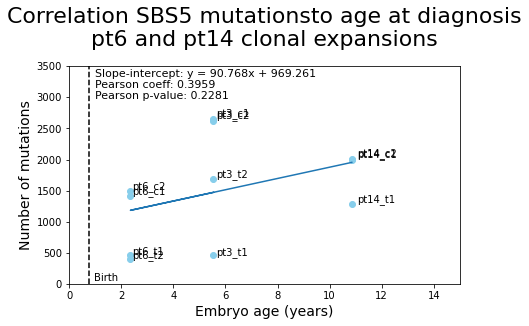

In [22]:
y_col = 'SBS5'
x_col = 'age_embryo'
xlabel = 'Embryo age (years)'
y_min = 0
y_max = 3500
x_min = 0
x_max = 15
c = sbs_color_dict[y_col]
title = 'Correlation SBS5 mutationsto age at diagnosis\npt6 and pt14 clonal expansions'
plot_correlation(df2,x_col,y_col,xlabel,y_min,y_max,x_min,x_max,c,title)
plt.vlines(3/4,0,y_max,color='k',linestyle='--')
plt.text(3/4+0.2,50,s='Birth')
plt.show()

## Plots with only clonal epxansions samples

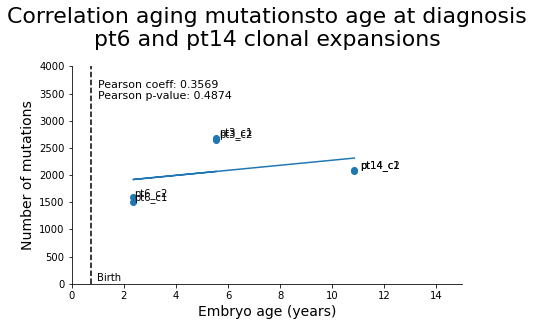

In [23]:
df3 = df2[df2.index.isin(['pt3_c1','pt3_c2','pt6_c1','pt6_c2','pt14_c1','pt14_c2'])]
y_col = 'aging'
x_col = 'age_embryo'
xlabel = 'Embryo age (years)'
y_min = 0
y_max = 4000
x_min = 0
x_max = 15
c = '#1f77b4' 
title = 'Correlation aging mutationsto age at diagnosis\npt6 and pt14 clonal expansions'
plt.figure(figsize=(7,4))
x = df3[x_col]
y = df3[y_col]
plt.scatter(x=x,y=y,c=c)
b, m = polyfit(x, y, 1)
plt.plot(x, b + m * x, '-')

plt.xlim(x_min,x_max)
plt.ylim(y_min,y_max)

for sample in df3.index:
    color = 'k'
    x1 = df3[x_col][(df3.index==sample)][sample]
    y1 = df3[y_col][(df3.index==sample)][sample]
    plt.text(x1*1.02,y1*1.02,s=sample,color=color)
plt.title(title,size=22,pad=20)
plt.ylabel('Number of mutations',size=14)
plt.xlabel(xlabel,size=14)


# plt.text(x=x_min+1,y=y_max*0.95,s='Slope-intercept: y = '+str(round(m,3))+'x + '+str(round(b,3)),size=11)

pearson_coef_pval = stats.pearsonr(x=x,y=y)
pearson_coef = round(pearson_coef_pval[0],4)
pearson_pval = round(pearson_coef_pval[1],4)

plt.text(x=x_min+1,y=y_max*0.9,s='Pearson coeff: '+str(pearson_coef),size=11)
plt.text(x=x_min+1,y=y_max*0.85,s='Pearson p-value: '+str(pearson_pval),size=11)
# plot_correlation(df3,x_col,y_col,xlabel,y_min,y_max,x_min,x_max,c,title)
plt.vlines(3/4,0,y_max,color='k',linestyle='--')
plt.text(3/4+0.2,50,s='Birth')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

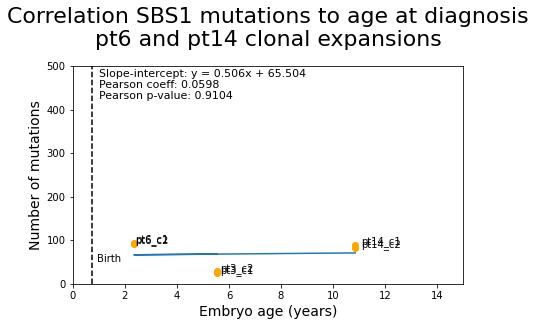

In [24]:
y_col = 'SBS1'
x_col = 'age_embryo'
xlabel = 'Embryo age (years)'
y_min = 0
y_max = 500
x_min = 0
x_max = 15
c = sbs_color_dict[y_col]
title = 'Correlation SBS1 mutations to age at diagnosis\npt6 and pt14 clonal expansions'
plot_correlation(df3,x_col,y_col,xlabel,y_min,y_max,x_min,x_max,c,title)
plt.vlines(3/4,0,y_max,color='k',linestyle='--')
plt.text(3/4+0.2,50,s='Birth')
plt.show()

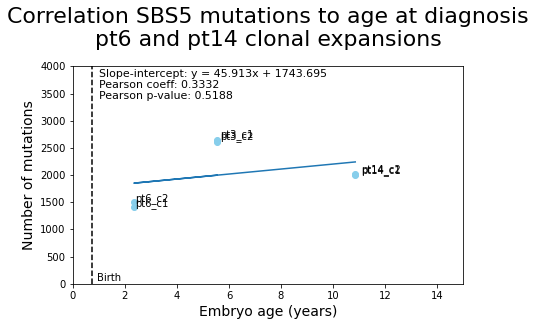

In [25]:
y_col = 'SBS5'
x_col = 'age_embryo'
xlabel = 'Embryo age (years)'
y_min = 0
y_max = 4000
x_min = 0
x_max = 15
c = sbs_color_dict[y_col]
title = 'Correlation SBS5 mutations to age at diagnosis\npt6 and pt14 clonal expansions'
plot_correlation(df3,x_col,y_col,xlabel,y_min,y_max,x_min,x_max,c,title)
plt.vlines(3/4,0,y_max,color='k',linestyle='--')
plt.text(3/4+0.2,50,s='Birth')
plt.show()

## Add the table with mutrate from clonal tumor mutations

In [26]:
mutrate_clonal_df = pd.read_csv('data/mutrate_clonal_muts.tsv',sep='\t')
mutrate_clonal_df

,sample,SBS1,SBS5,clonal_aging_sigs,age,SBS1_per_mb,SBS5_per_mb,clonal_aging_sigs_per_mb,2copies_mut_per_mb,1copy_mut_per_mb,CNLOH,cnloh_length,age_embryo,mutrate_clonal_age_embryo
0,PABKLN,72.0,617,689,1.10,0.028292,0.242444,0.270735,0.000000,0.000000,False,0.0,1.85,0.146343
1,PADWRZ,80.0,357,437,1.05,0.031435,0.140279,0.171715,0.031596,0.252768,True,31649585.0,1.80,0.095397
2,PADYZI,0.0,0,0,2.97,0.000000,0.000000,0.000000,0.000000,0.000000,False,0.0,3.72,0.000000
3,PAEHIP,62.0,118,180,0.48,0.024362,0.046367,0.070729,0.028479,0.028479,True,35114034.0,1.23,0.057503
4,PAJLWM,52.0,169,221,0.79,0.020433,0.066407,0.086840,0.000000,0.061315,True,32618353.0,1.54,0.056389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,pt6_t2,104.0,463,567,1.64,0.040866,0.181931,0.222797,0.000000,0.231929,True,30181611.0,2.39,0.093220
103,pt7_t1,0.0,0,0,2.25,0.000000,0.000000,0.000000,0.000000,0.000000,False,27000780.0,3.00,0.000000
104,pt8_t1,157.0,318,475,3.02,0.061692,0.124955,0.186646,0.028389,0.113555,True,35225172.0,3.77,0.049508
105,pt9_t1,0.0,0,0,0.44,0.000000,0.000000,0.000000,0.000000,0.000000,False,0.0,1.19,0.000000


In [27]:
mappable_counts = json.load(open('mappable_genome/hg38_mappable_genome.trinucleotide_counts.json','rb'))
mappable_length = 0
counts_list = [ mappable_counts[triplet] for triplet in mappable_counts.keys()]
mappable_length = sum(counts_list)
mappable_length

2544920035

In [28]:
tab_dict = {'pt6_t1':1.60,
            'pt6_t2':1.64,
            'pt3_t1':4.79,
            'pt3_t2':6.16,
            'pt14_t1' :10.10}

tab2_dict = {pt.split('_')[0]:tab_dict[pt] for pt in [t for t in tab_dict.keys() if '_t1' in t]}
tab2_dict

{'pt6': 1.6, 'pt3': 4.79, 'pt14': 10.1}

In [29]:
df2['age'] = df2.index.map(lambda x: tab2_dict.get(x.split('_')[0],np.nan))
df2['age_embryo'] = df2['age'] + 3/4
df2['clonal_aging_sigs_per_mb'] = df2['aging'] / mappable_length * 1000000
df2['mutrate_clonal_age_embryo'] = df2['clonal_aging_sigs_per_mb'] / df2['age_embryo']
df2['muts_per_year'] = df2['aging'] / df2['age_embryo']
df2

,SBS1,SBS2,SBS5,SBS13,SBS18,SBS84,age,age_embryo,aging,clonal_aging_sigs_per_mb,mutrate_clonal_age_embryo,muts_per_year
Samples2,,,,,,,,,,,,
pt3_t1,102,0,456,0,128,0,4.79,5.54,558,0.219260,0.039578,100.722022
pt3_t2,150,0,1691,0,0,0,4.79,5.54,1841,0.723402,0.130578,332.310469
pt3_c1,25,0,2652,0,1722,0,4.79,5.54,2677,1.051899,0.189874,483.212996
pt3_c2,29,0,2617,0,1647,0,4.79,5.54,2646,1.039718,0.187675,477.617329
pt6_t1,102,40,465,0,197,0,1.60,2.35,567,0.222797,0.094807,241.276596
pt6_t2,96,40,403,19,159,0,1.60,2.35,499,0.196077,0.083437,212.340426
pt6_c1,94,0,1409,0,508,0,1.60,2.35,1503,0.590588,0.251314,639.574468
pt6_c2,91,0,1499,0,557,0,1.60,2.35,1590,0.624774,0.265861,676.595745
pt14_t1,74,0,1283,0,0,0,10.10,10.85,1357,0.533219,0.049145,125.069124


In [30]:
samples_final_ids_dict = json.load(open("sample_ids/sample_ids_final.json", "rb"))

In [31]:
import matplotlib.gridspec as gridspec

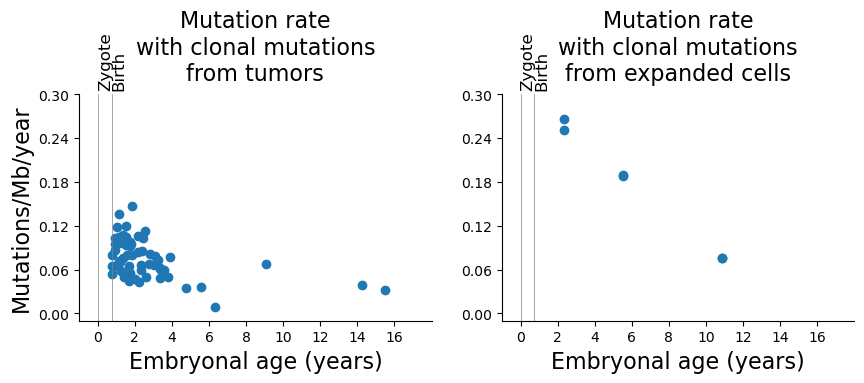

In [33]:
# fig, ax = plt.subplots(figsize=(6,4))
fig = plt.figure(figsize=(10,3), dpi=100)
gs = gridspec.GridSpec(1, 2)

excluded_sjd_samples = ['pt2_t1','pt9_t1','pt10_t1','pt14_t2','pt16_t1','pt18_t1','pt20_t1']
doublegermline_sample = ['PADYZI']
ttmt_dict = json.load(open('clinical_data/ttmt_dict.json','rb'))
treated_samples = [pt for pt in ttmt_dict.keys() if ttmt_dict[pt]!='naive'] 
excluded_samples =  excluded_sjd_samples + doublegermline_sample + treated_samples
    
df = mutrate_clonal_df[~mutrate_clonal_df['sample'].isin(excluded_samples)]

age_values = df['age_embryo'].values
    
y = df[f'mutrate_clonal_age_embryo']

ax0 = fig.add_subplot(gs[0])
ax0.scatter(age_values, y)
ax0.set_ylabel('Mutations/Mb/year',size=16)
ax0.set_xlabel('Embryonal age (years)',size=16)
ax0.set_xlim(-1,18)
ax0.set_ylim(-0.01,0.3)
ax0.set_xticks(range(0,18,2),size=14)
ax0.set_yticks(np.linspace(0,0.3,6),size=14)
ax0.set_title('Mutation rate\nwith clonal mutations\nfrom tumors',size=16,pad=10)

# fig.tight_layout()

ax0.axvline(3/4,color='grey',linewidth=0.5)
ax0.axvline(0,color='grey',linewidth=0.5)
ax0.text(3/4,0.31,s='Birth',rotation=90,size=12)
ax0.text(0,0.31,s='Zygote',rotation=90,size=12)

ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

df = df2[df2.index.isin(['pt3_c1','pt3_c2','pt6_c1','pt6_c2','pt14_c1','pt14_c2'])]

age_values = df['age_embryo'].values
    
y = df[f'mutrate_clonal_age_embryo']

ax1 = fig.add_subplot(gs[1])
ax1.scatter(age_values, y)
ax1.set_ylabel('')
ax1.set_xlabel('Embryonal age (years)',size=16)
ax1.set_xlim(-1,18)
ax1.set_ylim(-0.01,0.3)
ax1.set_xticks(range(0,18,2),size=14)
ax1.set_yticks(np.linspace(0,0.3,6),size=14)
ax1.set_title('Mutation rate\nwith clonal mutations\nfrom expanded cells',size=16,pad=10)

# fig.tight_layout()

ax1.axvline(3/4,color='grey',linewidth=0.5)
ax1.axvline(0,color='grey',linewidth=0.5)
ax1.text(3/4,0.31,s='Birth',rotation=90,size=12)
ax1.text(0,0.31,s='Zygote',rotation=90,size=12)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.savefig('plots/mutrate_tumors_vs_cells.svg', bbox_inches='tight',format='svg')



In [34]:
df2

,SBS1,SBS2,SBS5,SBS13,SBS18,SBS84,age,age_embryo,aging,clonal_aging_sigs_per_mb,mutrate_clonal_age_embryo,muts_per_year
Samples2,,,,,,,,,,,,
pt3_t1,102,0,456,0,128,0,4.79,5.54,558,0.219260,0.039578,100.722022
pt3_t2,150,0,1691,0,0,0,4.79,5.54,1841,0.723402,0.130578,332.310469
pt3_c1,25,0,2652,0,1722,0,4.79,5.54,2677,1.051899,0.189874,483.212996
pt3_c2,29,0,2617,0,1647,0,4.79,5.54,2646,1.039718,0.187675,477.617329
pt6_t1,102,40,465,0,197,0,1.60,2.35,567,0.222797,0.094807,241.276596
pt6_t2,96,40,403,19,159,0,1.60,2.35,499,0.196077,0.083437,212.340426
pt6_c1,94,0,1409,0,508,0,1.60,2.35,1503,0.590588,0.251314,639.574468
pt6_c2,91,0,1499,0,557,0,1.60,2.35,1590,0.624774,0.265861,676.595745
pt14_t1,74,0,1283,0,0,0,10.10,10.85,1357,0.533219,0.049145,125.069124


567 499 639.5744680851063 676.595744680851
558 1841 483.2129963898917 477.6173285198556
1357 NA 192.073732718894 193.08755760368663


/tmp/ipykernel_1495348/2455649921.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  num_aging_tumor1 = df2['aging'][df2.index==pt+'_t1'][0]
/tmp/ipykernel_1495348/2455649921.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  num_aging_tumor2 = df2['aging'][df2.index==pt+'_t2'][0]
/tmp/ipykernel_1495348/2455649921.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age1 = df2['age_embryo'][df2.index==pt+'_t1'][0]
/tmp/ipykernel_14

Text(3.0, -0.25, '1st Trimester')

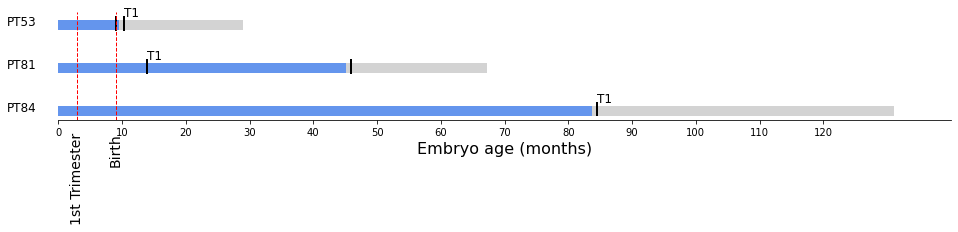

In [36]:
plt.figure(figsize=(16,2))
ax = plt.subplot(111)
n = 0
for pt in ['pt6','pt3','pt14']:
    y = 0 + n
    if pt != 'pt14':
        num_aging_tumor1 = df2['aging'][df2.index==pt+'_t1'][0]
        num_aging_tumor2 = df2['aging'][df2.index==pt+'_t2'][0]
        age1 = df2['age_embryo'][df2.index==pt+'_t1'][0]
        age2 = df2['age_embryo'][df2.index==pt+'_t2'][0]
    else:
        num_aging_tumor1 = df2['aging'][df2.index==pt+'_t1'][0]
        age1 = df2['age_embryo'][df2.index==pt+'_t1'][0]
        num_aging_tumor2 = 'NA'

    c1 = pt+'_c1'
        
    mut_per_year1 = df2['muts_per_year'][df2.index==c1][0]
    c2 = pt+'_c2'
    mut_per_year2 = df2['muts_per_year'][df2.index==c2][0]
    
    
    print(num_aging_tumor1,num_aging_tumor2,mut_per_year1,mut_per_year2)
    
    if num_aging_tumor2 != 'NA':
        max_num_aging_tumor = max(num_aging_tumor1,num_aging_tumor2)
        age = max(age1,age2)
    else:
        max_num_aging_tumor = num_aging_tumor1
        age= age1
    
    x1 = 0
    x2 = max_num_aging_tumor/((mut_per_year1+mut_per_year2)/2)*12
    x3 = age*12
    t1 = num_aging_tumor1/((mut_per_year1+mut_per_year2)/2)*12
    plt.plot([x1,x2],[y,y],linewidth=10,color='cornflowerblue')
    plt.plot([x2,x3],[y,y],linewidth=10,color='lightgrey')
    plt.plot([t1,t1],[y-0.01,y+0.02],linewidth=2,color='k',linestyle='-')
    plt.text(t1,y+0.02,s='T1',size=12)
    if num_aging_tumor2 != 'NA':
        t2 = num_aging_tumor2/((mut_per_year1+mut_per_year2)/2)*12
        plt.plot([t2,t2],[y-0.01,y+0.02],linewidth=2,color='k',linestyle='-') 
    pt_final = samples_final_ids_dict[pt.split('_')[0]]
    plt.text(-8,y,s=pt_final,ha='left',size=12)
    ax.spines[['right', 'top','left']].set_visible(False)
    n = n - 0.1
plt.xticks(range(-10,130,10))
plt.xlim(0,140)
plt.yticks([])
plt.xlabel('Embryo age (months)',size=16)
plt.axvline(3/4*12,color='r',linestyle='--',linewidth=1)
plt.text(3/4*12,y-0.05,s='Birth',size=14,rotation=90,ha='center',va='top')
plt.axvline(3/4/3*12,color='r',linestyle='--',linewidth=1)
plt.text(3/4/3*12,y-0.05,s='1st Trimester',size=14,rotation=90,ha='center',va='top')

In [37]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches

In [38]:
pts = ['pt6','pt3','pt14']

/tmp/ipykernel_1495348/2253940534.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  num_aging_tumor1 = df2['aging'][df2.index==pt+'_t1'][0]
/tmp/ipykernel_1495348/2253940534.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  num_aging_tumor2 = df2['aging'][df2.index==pt+'_t2'][0]
/tmp/ipykernel_1495348/2253940534.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age1 = df2['age_embryo'][df2.index==pt+'_t1'][0]
/tmp/ipykernel

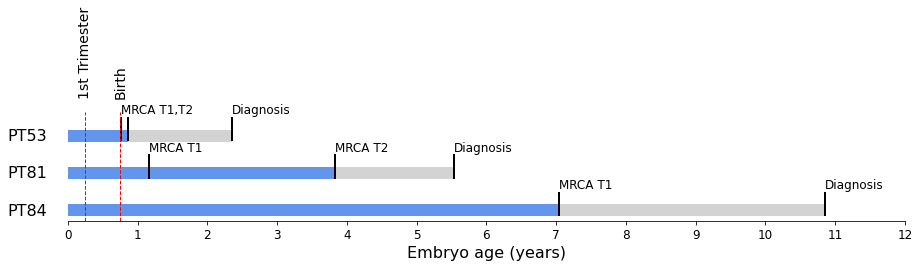

In [39]:
plt.figure(figsize=(15, 2))
ax = plt.gca()

y = 0
for n, pt in enumerate(pts):    
    # if n != 0:
    #     ax = fig.add_subplot(gs[n,0],sharex=ax)
    # else:
    #     ax = ax = fig.add_subplot(gs[n,0])
    
    # ax.spines['right'].set_visible(False)
    # ax.spines['top'].set_visible(False)
    # ax.spines['left'].set_visible(False)
    # ax.spines['bottom'].set_visible(False)
    
    # ax.set_xticks([]) 
    # ax.set_yticks([])
    # ax.set_xlim(0,18)
    # ax.set_ylim(0,1)
    
    if pt != 'pt14':
        num_aging_tumor1 = df2['aging'][df2.index==pt+'_t1'][0]
        num_aging_tumor2 = df2['aging'][df2.index==pt+'_t2'][0]
        age1 = df2['age_embryo'][df2.index==pt+'_t1'][0]
        age2 = df2['age_embryo'][df2.index==pt+'_t2'][0]
    else:
        num_aging_tumor1 = df2['aging'][df2.index==pt+'_t1'][0]
        age1 = df2['age_embryo'][df2.index==pt+'_t1'][0]
        num_aging_tumor2 = 'NA'

    c1 = pt+'_c1'
    mut_per_year1 = df2['muts_per_year'][df2.index==c1][0]
    c2 = pt+'_c2'
    mut_per_year2 = df2['muts_per_year'][df2.index==c2][0]
    
    if num_aging_tumor2 != 'NA':
        max_num_aging_tumor = max(num_aging_tumor1,num_aging_tumor2)
        age = max(age1,age2)
    else:
        max_num_aging_tumor = num_aging_tumor1
        age= age1
    
    x1 = 0
    x2 = max_num_aging_tumor/((mut_per_year1+mut_per_year2)/2)
    x3 = age
    t1 = num_aging_tumor1/((mut_per_year1+mut_per_year2)/2)

    
    # ax.add_patch(patches.Rectangle(xy=(0,0),width=x2,height=0.5,color='cornflowerblue',hatch='/'))
    # ax.add_patch(patches.Rectangle(xy=(x2,0),width=x3,height=0.5,color='lightgrey',hatch='/'))

    # ax.add_patch(patches.Rectangle(xy=(t1,0),width=0.02,height=1.2,color='k'))
    
    ax.hlines(y=y, xmin=0, xmax=x2, color='cornflowerblue', linewidth=12)
    ax.hlines(y=y, xmin=x2, xmax=x3, color='lightgrey', linewidth=12)
    
    if pt == 'pt3':
        ax.vlines(x=t1, ymin=y-0.15, ymax=y+0.5, color='k', linewidth=2)
        ax.text(x=t1,y=y+0.6,s='MRCA T1',ha='left',size=12)
        t2 = num_aging_tumor2/((mut_per_year1+mut_per_year2)/2)
        ax.vlines(x=t2, ymin=y-0.15, ymax=y+0.5, color='k', linewidth=2)
        ax.text(x=t2,y=y+0.6,s='MRCA T2',size=12)
    elif pt == 'pt6':
        t2 = num_aging_tumor2/((mut_per_year1+mut_per_year2)/2)
        ax.vlines(x=t1, ymin=y-0.15, ymax=y+0.5, color='k', linewidth=2)
        ax.vlines(x=t2, ymin=y-0.15, ymax=y+0.5, color='k', linewidth=2)
        ax.text(x=t2,y=y+0.6,s='MRCA T1,T2',size=12)
    else:
        ax.vlines(x=t1, ymin=y-0.15, ymax=y+0.5, color='k', linewidth=2)
        ax.text(x=t1,y=y+0.6,s='MRCA T1',ha='left',size=12)
    
    ax.vlines(x=x3, ymin=y-0.15, ymax=y+0.5, color='k', linewidth=2)
    ax.text(x=x3,y=y+0.6,s='Diagnosis',size=12)
        
    
    title = samples_final_ids_dict[pt]
    ax.text(x=-0.3,y=y,s=title,fontsize=16,ha='right',va='center') #Title
    
    y -= 1

ax.set_xticks(range(0,13,1))
ax.set_xticklabels(range(0,13,1),size=12)
ax.set_xlim(0,12)
ax.set_yticks([])
ax.set_xlabel('Embryo age (years)',size=16)

ax.axvline(3/4,color='r',linestyle='--',linewidth=1)
ax.text(3/4,1,s='Birth',size=14,rotation=90,ha='center',va='bottom')
ax.axvline(3/4/3,color='r',linestyle='--',linewidth=1)
ax.text(3/4/3,1,s='1st Trimester',size=14,rotation=90,ha='center',va='bottom')
    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
ax.set_yticks([]) 

plt.savefig('plots/MRCA_absolute_timing_with_cell_lines.svg', bbox_inches='tight',format='svg')